### Red wine dataset classification, dataset optimization attempts, version 2

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np
import random
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

# pip install xgboost
from xgboost import XGBClassifier


In [73]:
df = pd.read_csv("winequality-red.csv")

### Optimizations - SMOTE

In [74]:
# Separate features and target
X = df.drop('quality', axis=1)
y = df['quality']

# Apply SMOTE to the dataset
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y)

# Combine resampled features and target into a new DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['quality'] = y_resampled

# # Display original class distribution
# print("Original class distribution:")
# print(df['quality'].value_counts())

# # Visualize original distribution
# sns.countplot(x='quality', data=df)
# plt.title('Original Class Distribution')
# plt.show()

# # Display new class distribution
# print("New class distribution after SMOTE:")
# print(df_resampled['quality'].value_counts())

# # Visualize new distribution
# sns.countplot(x='quality', data=df_resampled)
# plt.title('Class Distribution After SMOTE')
# plt.show()

synthetic_df = df_resampled[~df_resampled.isin(df).all(axis=1)]

# use the resampled DataFrame
# df = df_resampled
authentic_df = df.copy()
df = synthetic_df


In [75]:
# THIS IS NOT OPTIMAL SOLUTION FOR THIS
# REWRITE LATER 

# max threshold for majority classes
threshold = 53

# temporary list to containe sample rows
sampled_data = []

for quality, group in authentic_df.groupby('quality'):
    # if a minority group, just add all the data
    if len(group) <= threshold:
        sampled_data.append(group)
    else:
        sampled_data.append(group.sample(threshold))


# combine all data in the sample list
authentic_sample = pd.concat(sampled_data)

# drop the selected data from the original data
#print(len(authentic_df))
authentic_df = authentic_df.drop(authentic_sample.index)
#print(len(authentic_df))

# reset indexes
authentic_sample = authentic_sample.reset_index(drop=True)
authentic_df = authentic_df.reset_index(drop=True)

df = pd.concat([df, authentic_df])
df = df.reset_index(drop=True)

# remove any rows in df_train that also appear in df_other
df_clean = df.merge(authentic_sample, how='outer', indicator=True)
df_clean = df_clean[df_clean['_merge'] == 'left_only'].drop(columns=['_merge'])
df = df_clean

<Axes: >

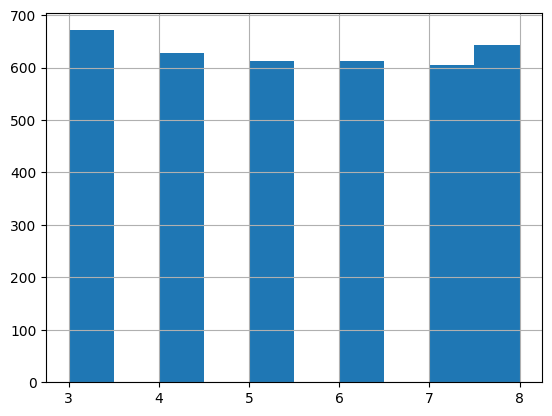

In [76]:
df['quality'].hist()

<Axes: >

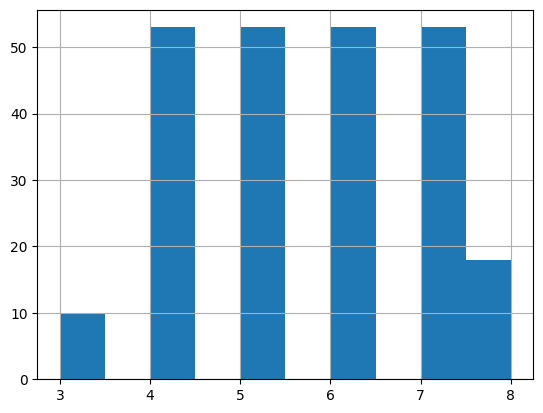

In [77]:
authentic_sample['quality'].hist()

### In order to to get our metrics to be more realistic, let's reserve the real wines as test dataset in the future

In [78]:
# TODO: reserve the original real wines as the testing dataset after generating the synthetic ones

### Since this dataset suffers from overlapping between qualities 5 and 6 (middle range wines), TomekLinks is probably a good idea

In [79]:
# initialize TomekLinks
# TomekLinks is used to reduce data overlap throughout the dataset
# howewer, we can't really configure its parameters
tomek = TomekLinks()

# X/y -split
X = df.drop("quality", axis=1)
y = df['quality']

# create new resampled versions of X and y
X_resampled, y_resampled = tomek.fit_resample(X, y)

# re-create a new DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['quality'] = y_resampled

df = df_resampled

### Add some slight outlier removal (Isolation Forest)

In [80]:
# can process the whole dataset 
# and compares variables to each other instead
# of focusing on outliers on a single variable
from sklearn.ensemble import IsolationForest
import pandas as pd

# adjust the contamination rate as you see fit
# for example, if you expect 5% of the data to be outliers
# you can use 0.05 etc. 

# basically, this is how aggressive Isolation Forest will be
# increase if you think you need to detect more outliers
# decrease if you need less outliers
iso = IsolationForest(contamination=0.015) 

# fit isolation forest
y_pred = iso.fit_predict(df)

# separate outliers and inliers into separate DataFrames
outliers = df[y_pred != 1]
inliers = df[y_pred == 1]

print(f"Inliers: {len(inliers)}")
print(f"Outliers: {len(outliers)}")

# use the inliers as the new DataFrame
df = inliers

Inliers: 3547
Outliers: 54


### Use clustering to help out the model in differentiating between the qualities (especially with the qualities 5 and 6)

In [81]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,4.636310,0.526884,0.148336,2.098487,0.054499,8.060516,65.030258,0.993434,3.891679,0.560605,13.044023,4
1,4.802598,0.558409,0.140714,2.091558,0.056786,8.337664,65.168832,0.993590,3.853571,0.563377,12.787661,4
2,4.859910,0.569275,0.138087,2.089170,0.057574,8.433183,65.216592,0.993644,3.840437,0.564332,12.699305,4
3,4.878432,0.547843,0.138067,2.195462,0.057341,9.431936,64.681792,0.993945,3.876134,0.572728,12.837478,4
4,5.000000,0.740000,0.000000,1.200000,0.041000,16.000000,46.000000,0.992580,4.010000,0.590000,12.500000,6
...,...,...,...,...,...,...,...,...,...,...,...,...
3591,14.021779,0.250018,0.573394,2.377858,0.083893,9.555354,25.778583,0.999761,3.127804,0.808875,9.911433,7
3592,14.186578,0.243276,0.550921,2.347895,0.082395,9.630263,25.478950,0.999810,3.118066,0.814118,9.791580,7
3596,15.500000,0.645000,0.490000,4.200000,0.095000,10.000000,23.000000,1.003150,2.920000,0.740000,11.100000,5
3597,15.500000,0.645000,0.490000,4.200000,0.095000,10.000000,23.000000,1.003150,2.920000,0.740000,11.100000,5


### Train/test -split

In [82]:
# X = df.drop("quality", axis=1)
# y = df['quality']

In [83]:
categories = list(np.unique(df['quality']))


# encode the target from original 3, 4, 5, 6, 7, 8 to 0, 1, 2, 3, 4, 5
le = LabelEncoder()
# y = le.fit_transform(y)

# stratify can be used to ensure data balance between train/test -datasets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)
X_train = df.drop("quality", axis=1)
y_train = df['quality']
y_train = le.fit_transform(y_train)

X_test = authentic_sample.drop("quality", axis=1)
y_test = authentic_sample["quality"]
y_test = le.transform(y_test)


### XGBoost classifier

In [84]:
# create XGboost model
model = XGBClassifier(
    objective="multi:softmax",
    num_class=len(categories),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

# fit the model / start training
model.fit(X_train, y_train)

,objective,'multi:softmax'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Metrics

In [85]:
test_predictions = model.predict(X_test)

<Axes: >

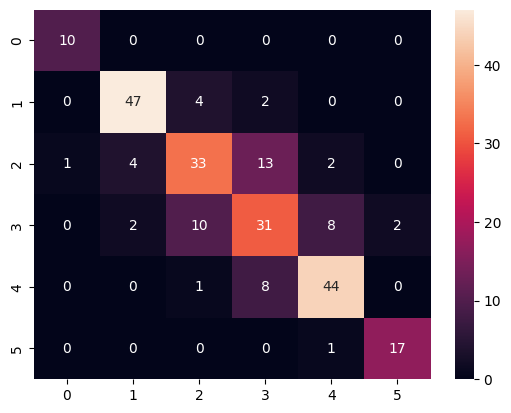

In [86]:
sns.heatmap(confusion_matrix(y_test, test_predictions), annot=True, fmt='g')


In [87]:
print(classification_report(y_test, test_predictions))

acc = accuracy_score(y_test, test_predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       0.89      0.89      0.89        53
           2       0.69      0.62      0.65        53
           3       0.57      0.58      0.58        53
           4       0.80      0.83      0.81        53
           5       0.89      0.94      0.92        18

    accuracy                           0.76       240
   macro avg       0.79      0.81      0.80       240
weighted avg       0.76      0.76      0.76       240


Model overall accuracy: 75.83%


More than 60% of our data is synthetic, which was generated by SMOTE.

Additionally, 99% of data in certain categories are synthetic.

It might be this result is overly optimistic.

IDEA:

Use the real wines as testing dataset, and use synthetic wines as training dataset.